In [154]:
!pip install optuna


In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
from scipy import stats


import time
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import re
import optuna

import warnings
warnings.filterwarnings("ignore")
import joblib


pd.set_option('display.float', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore")

In [156]:
train = pd.read_csv("/content/drive/MyDrive/DS-Projects/Datasets/01-Retail-Demand-Rossman/train.csv")
stores = pd.read_csv("/content/drive/MyDrive/DS-Projects/Datasets/01-Retail-Demand-Rossman/store.csv")

In [157]:
def num_summary(dataframe, numerical_col, plot=False):
  quantiles = [0.25, 0.50, 0.75, 1]

  print("//////////// Summary Statistics of " + numerical_col + "\\\\\\\\\\\\" )
  print(dataframe[numerical_col].describe(quantiles).T)

  if plot:
    sns.histplot(data = dataframe , x = numerical_col)
    plt.xlabel(numerical_col)
    plt.title("The Distribution of " + numerical_col)
    plt.grid(True)
    plt.show(block = True)

In [158]:
def missing_ratio(df: pd.DataFrame, column_name: str):
  if column_name not in df.columns:
        raise ValueError(f"ERROR: A column named '{column_name}' could not be found in the DataFrame.")

  total_rows = len(df)
  if total_rows == 0:
        print("WARNING: The data frame is empty. The loss rate cannot be calculated.")
        return 0.0


  missing_count = df[column_name].isnull().sum()
  ratio = missing_count / total_rows
  print("-" * 40)
  print(f"Missing Data Analysis: Column '{column_name}'")
  print("-" * 40)
  print(f"Total Number of Rows: {total_rows}")
  print(f"Missing Rows: {missing_count}")
  print(f"Decimal Loss Rate: {ratio:.2f}")
  print("-" * 40)

In [159]:
def cat_summary(dataframe,column_name, plot = False):
   print("############## Unique Observations of Categorical Data ###############")

   nunique_val = dataframe[column_name].nunique()
   print("The unique number of " + column_name + ": " + str(nunique_val))

   print("############## Frequency of Categorical Data ########################")
   print(pd.DataFrame({column_name: dataframe[column_name].value_counts(),
                        "Ratio": dataframe[column_name].value_counts() / len(dataframe)}))
   if plot == True:
    rgb_values = sns.color_palette("Set2", nunique_val)
    sns.set_theme(style="darkgrid")
    ax = sns.countplot(x=dataframe[column_name],
                           data=dataframe,
                           palette=rgb_values,
                           hue=dataframe[column_name],
                           legend=False)
    for p in ax.patches:
      ax.annotate(f'\n{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='top', color='white', size=10)
    plt.show()


In [160]:
def desc_stats(dataframe):
    desc = dataframe.describe().T
    desc_df = pd.DataFrame(index= dataframe.columns,
                           columns= desc.columns,
                           data= desc)

    f,ax = plt.subplots(figsize=(15,
                                 desc_df.shape[0]*0.78))
    sns.heatmap(desc_df,
                annot=True,
                cmap = "Wistia",
                fmt= '.2f',
                ax=ax,
                linecolor='white',
                linewidths = 1.3,
                cbar = False,
                annot_kws={"size": 12})
    plt.xticks(size = 18)
    plt.yticks(size = 14,
               rotation = 0)
    plt.title("Descriptive Statistics", size = 14)
    plt.show()

In [161]:
def check_df(dataset, head = 5):
    print("-"*10 + ' Shape Information of Dataset ' + "-"*10, end = '\n'*2)
    print(f" The dataset consist of {dataset.shape[0]} rows & {dataset.shape[1]} columns", end = '\n'*2)
    print("-"*10 + ' General informations about to Dataset ' + "-"*10, end = '\n'*2)
    print(dataset.info(), end = '\n'*2)
    print("-"*10 + " Are there any null values in the dataset? " + "-"*10, end = '\n'*2)
    print(dataset.isnull().sum().sort_values(ascending = False), end = '\n'*2)
    print("-"*10 + " Are there any dublicated values in the dataset? " + "-"*10, end = '\n'*2)
    print(dataset[dataset.duplicated()].shape[0], end = '\n'*2)
    print("-"*10 + " What is the Number of Unique Classes in the Variables ? " + ' ' + "-"*10, end = '\n'*2)
    print(dataset.nunique(), end = '\n'*2)
    print('-'*10 + ' Descriptive Statistics of Numerical Features ' + "-"*10, end = '\n'*2)
    print(dataset.describe().T, end = '\n'*2)
    print("-"*10 + 'Quantiles of Numerical Features' + "-"*10, end ='\n'*2)
    print(dataset.describe([0,0.25, 0.50,0.75,1.0]).T, end = '\n'*2)

In [162]:
df = pd.merge(train, stores, on='Store', how='left')

In [163]:
df['Date'] = pd.to_datetime(df['Date'])

In [164]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

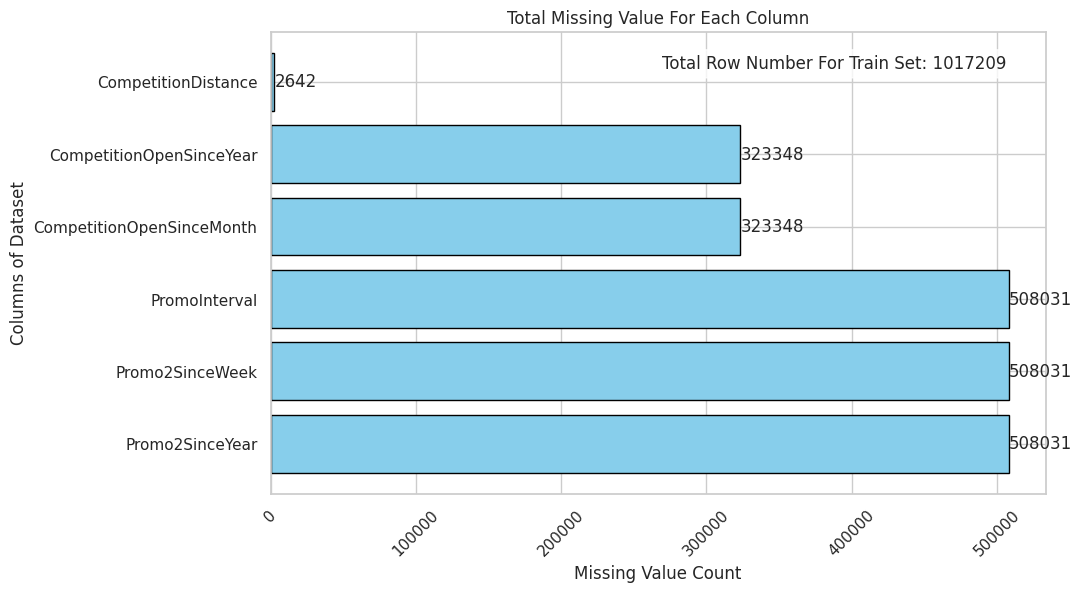

In [165]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False, inplace = True)

plt.figure(figsize=(10, 6))
bars = plt.barh(missing_values.index, missing_values.values, color='skyblue', edgecolor='black')
plt.title('Total Missing Value For Each Column')
plt.ylabel('Columns of Dataset')
plt.xlabel('Missing Value Count')
plt.xticks(rotation=45)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1.1,
             bar.get_y() + bar.get_height()/2,
             int(width),
             ha='left',
             va='center')
total_row = df.shape[0]
plt.text(0.95, 0.95, f'Total Row Number For Train Set: {total_row}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()
del missing_values

In [166]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

max_distance = df['CompetitionDistance'].max()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_distance)

<Figure size 1000x400 with 0 Axes>

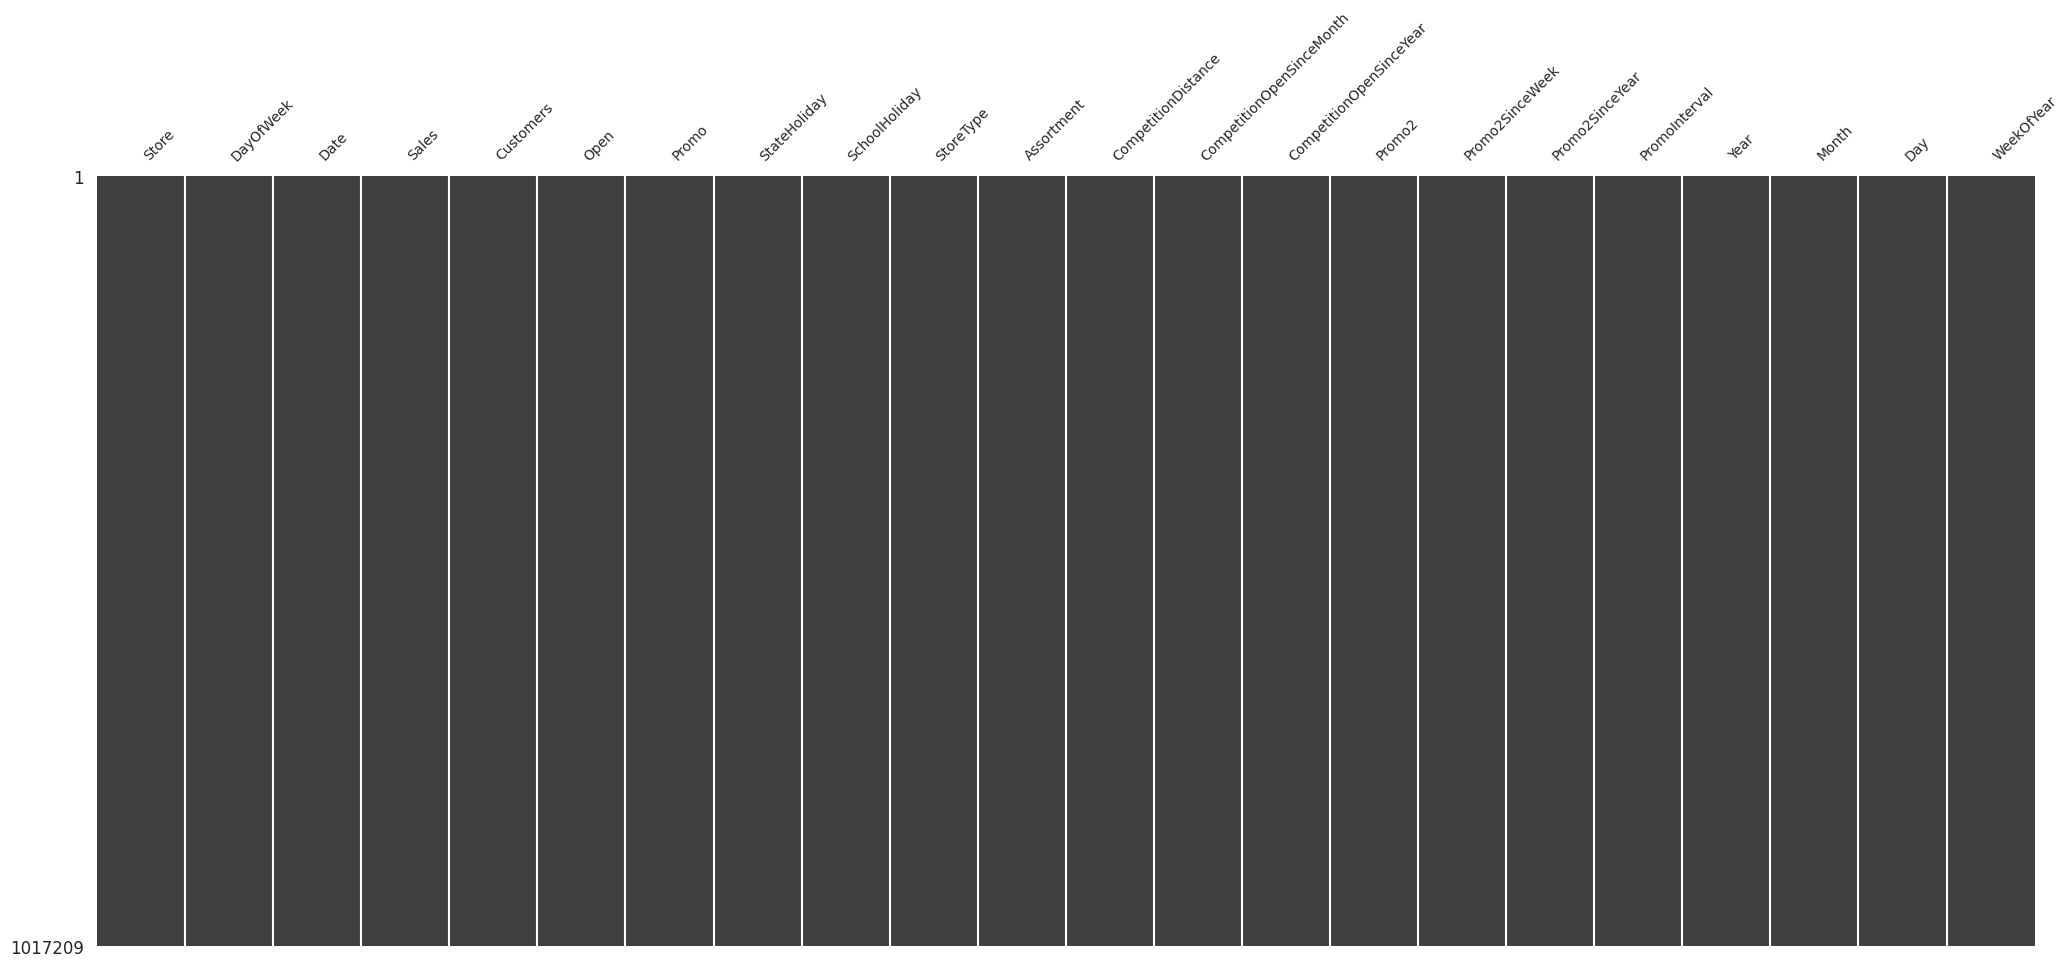

In [167]:
plt.figure(figsize=(10, 4))
msno.matrix(df, sparkline=False, fontsize=10)
plt.show()

## Explatory Data Analysis Phase :

--  Business Rule Filter: We only include days that are open and have sales.

In [168]:
df_open = df[(df['Open'] == 1) & (df['Sales'] > 0)]

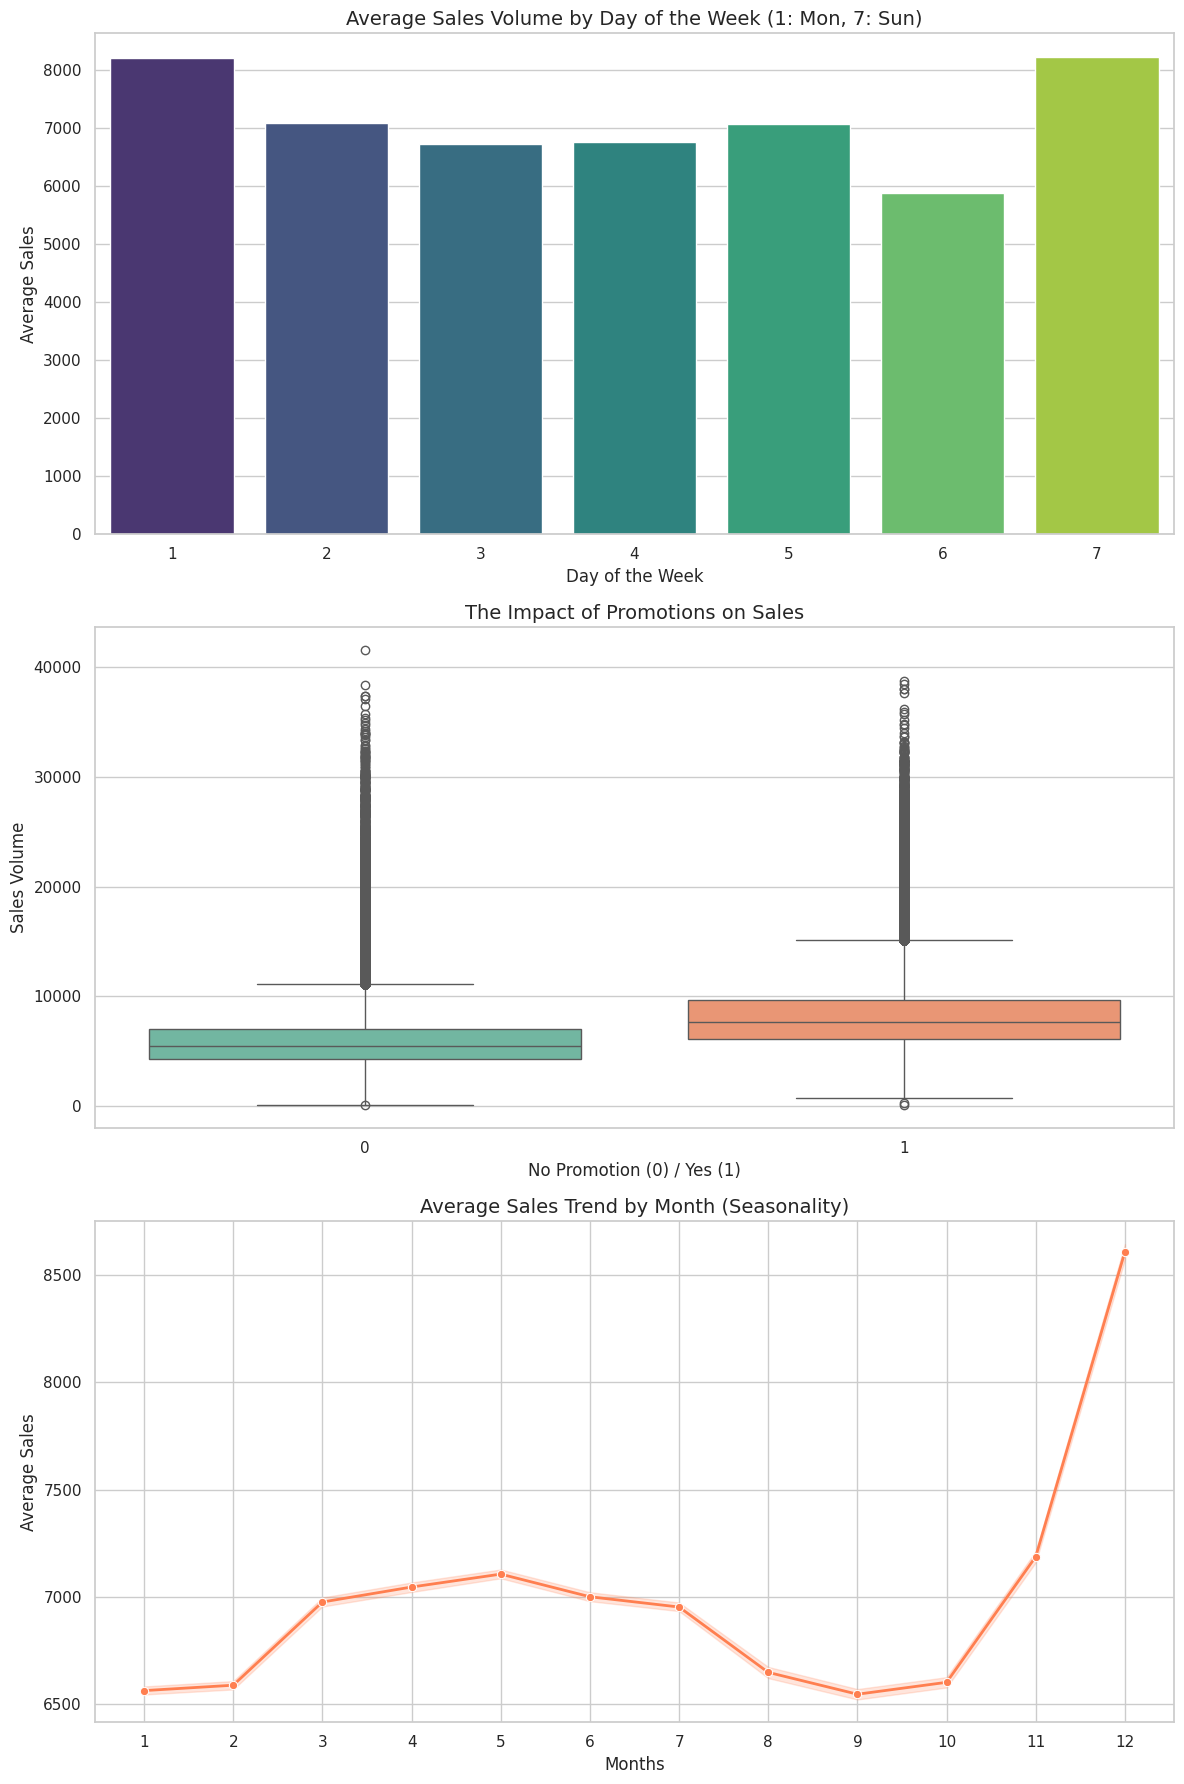

In [169]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(x='DayOfWeek', y='Sales', data=df_open, ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Average Sales Volume by Day of the Week (1: Mon, 7: Sun)', fontsize=14)
axes[0].set_ylabel('Average Sales')
axes[0].set_xlabel('Day of the Week')

sns.boxplot(x='Promo', y='Sales', data=df_open, ax=axes[1], palette='Set2')
axes[1].set_title('The Impact of Promotions on Sales', fontsize=14)
axes[1].set_ylabel('Sales Volume')
axes[1].set_xlabel('No Promotion (0) / Yes (1)')

sns.lineplot(x='Month', y='Sales', data=df_open, estimator=np.mean, ax=axes[2], marker='o', color='coral', linewidth=2)
axes[2].set_title('Average Sales Trend by Month (Seasonality)', fontsize=14)
axes[2].set_ylabel('Average Sales')
axes[2].set_xlabel('Months')
axes[2].set_xticks(range(1, 13))


plt.tight_layout()
plt.show()

In [192]:
df_eda = pd.merge(train, stores, on='Store', how='left')
df_eda = df_eda[(df_eda['Open'] == 1) & (df_eda['Sales'] > 0)]

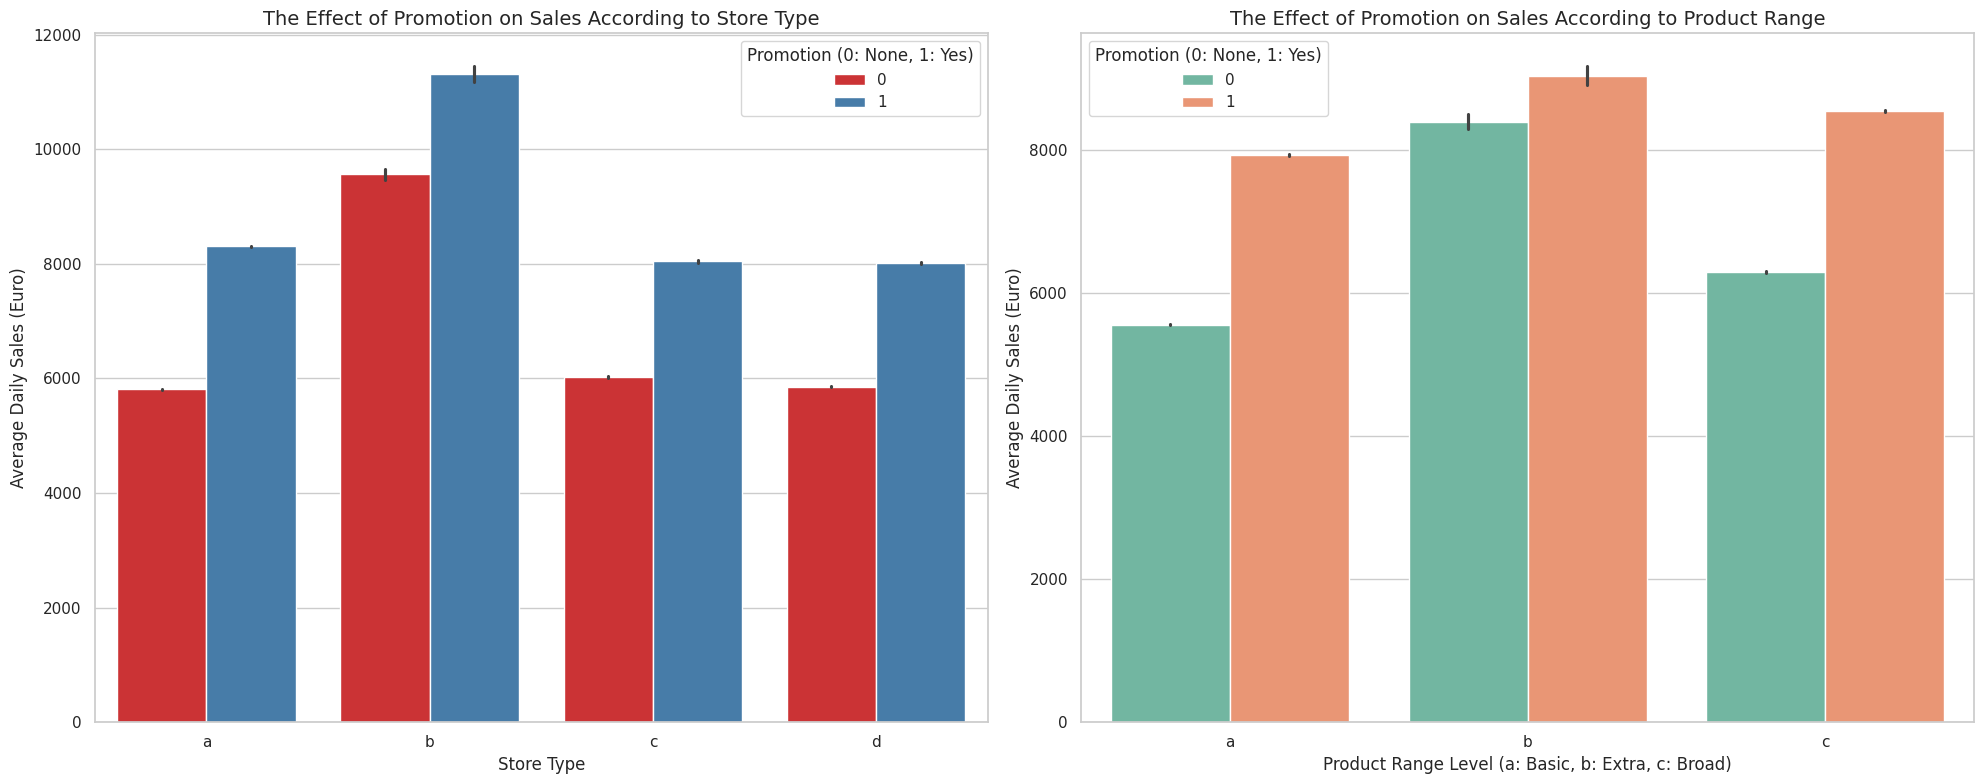

In [194]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='StoreType', y='Sales', hue='Promo', data=df_eda,
            order=['a', 'b', 'c', 'd'], palette='Set1', ax=axes[0])
axes[0].set_title('The Effect of Promotion on Sales According to Store Type', fontsize=14)
axes[0].set_ylabel('Average Daily Sales (Euro)')
axes[0].set_xlabel('Store Type')
axes[0].legend(title='Promotion (0: None, 1: Yes)')


sns.barplot(x='Assortment', y='Sales', hue='Promo', data=df_eda,
            order=['a', 'b', 'c'], palette='Set2', ax=axes[1])
axes[1].set_title('The Effect of Promotion on Sales According to Product Range', fontsize=14)
axes[1].set_ylabel('Average Daily Sales (Euro)')
axes[1].set_xlabel('Product Range Level (a: Basic, b: Extra, c: Broad)')
axes[1].legend(title='Promotion (0: None, 1: Yes)')

plt.tight_layout()
plt.show()

* Looking at the charts,
   * We can see that B-type stores both generate very high sales volumes and are not as dramatically affected by promotions as others, or they already have their own core customer base. B-type stores are generally large-volume stores with high circulation, such as those in train stations or airports, and are often open on Sundays.

* Action:
    
    * Allocating an aggressive promotional budget to B-type stores may reduce the return on investment (ROI). These stores already receive high traffic based on their location.

* When a customer visits a store on a promotional day, their basket size increases if there is a wide selection of products (c or b) available.

In [195]:
print("--- EXECUTIVE SUMMARY: Percentage Impact of Promotion (Lift) ---")

promo_impact = df_eda.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_impact.columns = ['No_Promo_Sales', 'Promo_Sales']

promo_impact['Lift_Percentage (%)'] = ((promo_impact['Promo_Sales'] - promo_impact['No_Promo_Sales']) / promo_impact['No_Promo_Sales']) * 100

print("\nPromotional Return Based on Store Type:")
display(promo_impact.round(2).sort_values(by='Lift_Percentage (%)', ascending=False))

--- EXECUTIVE SUMMARY: Percentage Impact of Promotion (Lift) ---

Promotional Return Based on Store Type:


,No_Promo_Sales,Promo_Sales,Lift_Percentage (%)
StoreType,,,
a,5809.05,8304.55,42.96
d,5855.39,8018.04,36.93
c,6028.55,8042.79,33.41
b,9567.86,11311.80,18.23


* Where Promotions Work Best (Budget Optimization)

    * Looking at the Lift_Percentage (%) column in the table above, we can clearly see that sales in standard street/mall stores of types A, C, or D surge by 40% to 50% on days when promotions are offered.

    * Action:
        * We should shift the lion's share of our promotion and marketing budget to A and C type stores. Every €1 spent on discounts/campaigns in these stores provides us with the highest marginal turnover.

## Hypothesis Test Phase : Statistically testing the differences in sales between days of the week And Statistically testing the differences in sales with Promo and Without Promo

In [170]:
promo_yes = df_open[df_open['Promo'] == 1]['Sales']
promo_no = df_open[df_open['Promo'] == 0]['Sales']

t_stat, p_val = stats.ttest_ind(promo_yes, promo_no, equal_var=False)

print(f"T-Stat: {t_stat:.4f}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("Result: The sales difference between days with and without promotion is statistically SIGNIFICANT (H0 Rejected).")
    print("Conclusion: The 'Promo' variable is a very critical attribute for the model.")
else:
    print("Result: The difference is random (H0 cannot be rejected).")

T-Stat: 356.6859
P-Value: 0.0
Result: The sales difference between days with and without promotion is statistically SIGNIFICANT (H0 Rejected).
Conclusion: The 'Promo' variable is a very critical attribute for the model.


In [171]:
days = [df_open[df_open['DayOfWeek'] == i]['Sales'] for i in range(1, 8)]

f_stat, p_value = stats.f_oneway(*days)

print(f"F-Stat: {f_stat:.4f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Result: The sales differences between days of the week are statistically SIGNIFICANT (H0 is Rejected).")
    print("Result: 'DayOfWeek' is a very powerful feature that will feed the model.")
else:
    print("Conclusion: The differences are random (H0 cannot be rejected).")

F-Stat: 7451.6122
P-Value: 0.0
Result: The sales differences between days of the week are statistically SIGNIFICANT (H0 is Rejected).
Result: 'DayOfWeek' is a very powerful feature that will feed the model.


## Feature Engineering :

In [172]:
# 1. Sorting data by store and date is essential!

# Otherwise, we might get information from store B instead of store A's sales from yesterday.

df_open.sort_values(['Store', 'Date'], ascending=[True, True], inplace=True)

In [173]:
# 2. Lag Features

# Sales from yesterday, last week, and 6 weeks (42 days) ago
df_open['Sales_Lag_1'] = df_open.groupby('Store')['Sales'].shift(1)
df_open['Sales_Lag_7'] = df_open.groupby('Store')['Sales'].shift(7)
df_open['Sales_Lag_42'] = df_open.groupby('Store')['Sales'].shift(42)

In [174]:
# 3. Rolling Window Features (Moving Averages)

# Average sales of the last 7 days and the last 30 days (To identify the trend)

df_open['Sales_Roll_Mean_7'] = df_open.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

df_open['Sales_Roll_Mean_30'] = df_open.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=30, min_periods=1).mean()
)

In [175]:
display(df_open[['Store', 'Date', 'Sales', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Roll_Mean_7']].head(10))

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Roll_Mean_7
1014980,1,2013-01-02,5530,NaN,NaN,NaN
1013865,1,2013-01-03,4327,5530.00,NaN,5530.00
1012750,1,2013-01-04,4486,4327.00,NaN,4928.50
1011635,1,2013-01-05,4997,4486.00,NaN,4781.00
1009405,1,2013-01-07,7176,4997.00,NaN,4835.00
1008290,1,2013-01-08,5580,7176.00,NaN,5303.20
1007175,1,2013-01-09,5471,5580.00,NaN,5349.33
1006060,1,2013-01-10,4892,5471.00,5530.00,5366.71
1004945,1,2013-01-11,4881,4892.00,4327.00,5275.57
1003830,1,2013-01-12,4952,4881.00,4486.00,5354.71


In [176]:
df_open.dropna(inplace=True)

## Data Check Before the Model Training :

In [177]:
total_missing = df_open.isnull().sum().sum()
print(f"Total Number of Missing Values: {total_missing}")
if total_missing > 0:
    print(df_open.isnull().sum()[df_open.isnull().sum() > 0])

print("\n--- Data Types That Machine Learning Doesn't Understand (Object / Datetime) ---")
bad_types = df_open.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()
print(bad_types)

print(f"\nTotal number of rows to be included in Model Training: {len(df_open)}")

Total Number of Missing Values: 0

--- Data Types That Machine Learning Doesn't Understand (Object / Datetime) ---
['Date', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']

Total number of rows to be included in Model Training: 797508


In [178]:
assortment_mapping = {'a': 1, 'c': 2, 'b': 3}
df_open['Assortment'] = df_open['Assortment'].map(assortment_mapping)

df_open['StateHoliday'] = df_open['StateHoliday'].astype(str)
df_open = pd.get_dummies(df_open, columns=['StoreType', 'StateHoliday', 'PromoInterval'], drop_first=True)

df_model_ready = df_open.drop(columns=['Date'])

print("Dataset size ready for modeling after encoding:", df_model_ready.shape)

print("\nNew Columns:\n", df_model_ready.columns.tolist())

Dataset size ready for modeling after encoding: (797508, 32)

New Columns:
 ['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_42', 'Sales_Roll_Mean_7', 'Sales_Roll_Mean_30', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None']


## Modelling Phase:

In [179]:
df_model_ready = df_model_ready.drop(columns=['Customers'])

y = df_model_ready['Sales']
X = df_model_ready.drop(columns=['Sales'])

In [180]:
val_condition = (X['Year'] == 2015) & (X['Month'] >= 6)

In [181]:
X_train = X[~val_condition]
y_train = y[~val_condition]

X_val = X[val_condition]
y_val = y[val_condition]

In [182]:
print(f"Training Set Size: X_train {X_train.shape}, y_train {y_train.shape}")

print(f"Validation Set Size: X_val {X_val.shape}, y_val {y_val.shape}")

Training Set Size: X_train (738897, 30), y_train (738897,)
Validation Set Size: X_val (58611, 30), y_val (58611,)


In [183]:
X_train = X_train.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_val = X_val.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
print("Here are some of the names of the new and cleaned columns.:")
print(X_train.columns[-3:])

Here are some of the names of the new and cleaned columns.:
Index(['PromoInterval_Jan_Apr_Jul_Oct', 'PromoInterval_Mar_Jun_Sept_Dec',
       'PromoInterval_None'],
      dtype='object')


In [184]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]

    error = np.sqrt(np.mean(((y_true_masked - y_pred_masked) / y_true_masked) ** 2))
    return error * 100

print("The models are being trained; this may take a few minutes depending on the computer's hardware...\n")


print("LightGBM training is starting...")
start_time = time.time()
lgbm_model = LGBMRegressor(n_estimators=500, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_val)
lgbm_rmspe = rmspe(y_val.values, lgbm_preds)
print(f"LightGBM Training Completed! Duration: {time.time() - start_time:.2f}")
print(f"LightGBM RMSPE Score: %{lgbm_rmspe:.2f}\n")

print("XGBoost training is starting...")
start_time = time.time()
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42, tree_method='hist')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_val)
xgb_rmspe = rmspe(y_val.values, xgb_preds)
print(f"XGBoost Training Completed! Duration: {time.time() - start_time:.2f} seconds")

print(f"XGBoost RMSPE Score: %{xgb_rmspe:.2f}\n")

The models are being trained; this may take a few minutes depending on the computer's hardware...

LightGBM training is starting...
LightGBM Training Completed! Duration: 29.99
LightGBM RMSPE Score: %13.47

XGBoost training is starting...
XGBoost Training Completed! Duration: 38.26 seconds
XGBoost RMSPE Score: %15.86



## Feature Importance :

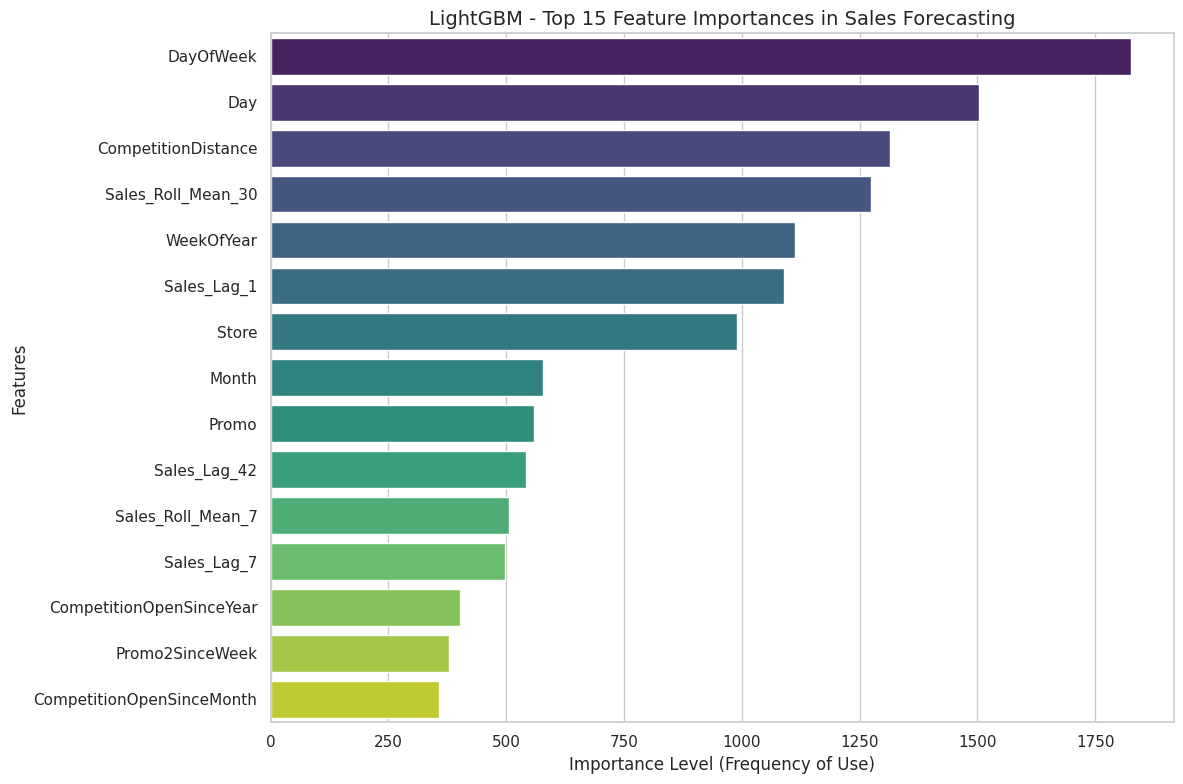

In [185]:
feature_imp = pd.DataFrame(sorted(zip(lgbm_model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(15), palette='viridis')
plt.title('LightGBM - Top 15 Feature Importances in Sales Forecasting', fontsize=14)
plt.xlabel('Importance Level (Frequency of Use)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Model Tuning :

In [186]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    model = LGBMRegressor(**param)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)


    mask = y_val.values != 0
    y_true_masked = y_val.values[mask]
    y_pred_masked = preds[mask]

    rmspe_score = np.sqrt(np.mean(((y_true_masked - y_pred_masked) / y_true_masked) ** 2)) * 100

    return rmspe_score

In [187]:
'''
print("Optuna optimization is starting... (It may take a few minutes depending on your hardware)")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)

print("\n--- Optimization Complete! ---")

print(f"Best RMSPE Score: %{study.best_value:.2f}")
print("Best Parameters:")
for key, value in study.best_params.items():
  print(f" {key}: {value}")
'''

Optuna optimization is starting... (It may take a few minutes depending on your hardware)

--- Optimization Complete! ---
Best RMSPE Score: %12.67
Best Parameters:
 n_estimators: 796
 learning_rate: 0.07822729976598285
 num_leaves: 97
 max_depth: 14
 min_child_samples: 21
 subsample: 0.7281588979759968
 colsample_bytree: 0.9012248028735335


Optuna optimization is starting... (It may take a few minutes depending on your hardware)

--- Optimization Complete! ---

Best RMSPE Score: %12.67

* Best Parameters:

    * n_estimators: 796

    * learning_rate: 0.07822729976598285

    * num_leaves: 97

    * max_depth: 14

    * min_child_samples: 21

    * subsample: 0.7281588979759968

    * colsample_bytree: 0.9012248028735335

In [189]:
best_params = {
    'n_estimators': 796,
    'learning_rate': 0.07822729976598285,
    'num_leaves': 97,
    'max_depth': 14,
    'min_child_samples': 21,
    'subsample': 0.7281588979759968,
    'colsample_bytree': 0.9012248028735335,
    'random_state': 42
}

print("Final Model is being trained with all training data...")

final_model = LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

joblib.dump(final_model, 'rossmann_model.pkl')
print("The model has been successfully saved as 'rossmann_model.pkl'!")

Final Model is being trained with all training data...
The model has been successfully saved as 'rossmann_model.pkl'!
